In [7]:
# Pytorch Workflow:
# Let explore the example Pytorch end to end workflow


In [8]:
import torch
from torch  import nn  # contains pytorch building blokcs for nns
import matplotlib.pyplot as plt

torch.__version__

'2.8.0+cu126'

In [9]:
# data preparing and loading
# Data can be anything in ML :
# Images, Videos spreadsheets, audio, table of numbers ..etc

# Machine learning:
# 1: get data into a numerical representation,
# 2: Build the model to learn patterns in that numerical representaion.




In [10]:
# create a *Known* parameter

weight = 0.7
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [11]:
len(X), len(y)


(50, 50)

In [12]:
# Splitting data into training and testing
# Creating proper train and test set is the most important part in ML
# Creating training and test set
tarin_split = int(0.8 * len(X))
X_train, y_train = X[:tarin_split], y[:tarin_split]
X_test, y_test = X[tarin_split:], y[tarin_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [13]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [14]:
import matplotlib.pyplot as plt

def plot_prediction(train_data=X_train,
                    train_label=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=None):
    """
    Plots training and test data, and compares predictions if provided.
    """
    plt.figure(figsize=(10, 7))

  # Plot training data
    plt.scatter(train_data, train_label, c="b", s=4, label="Training data")

  # Plot test data
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

  # Plot predictions if available
    if predictions is not None:
      plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14});
    # plt.show()


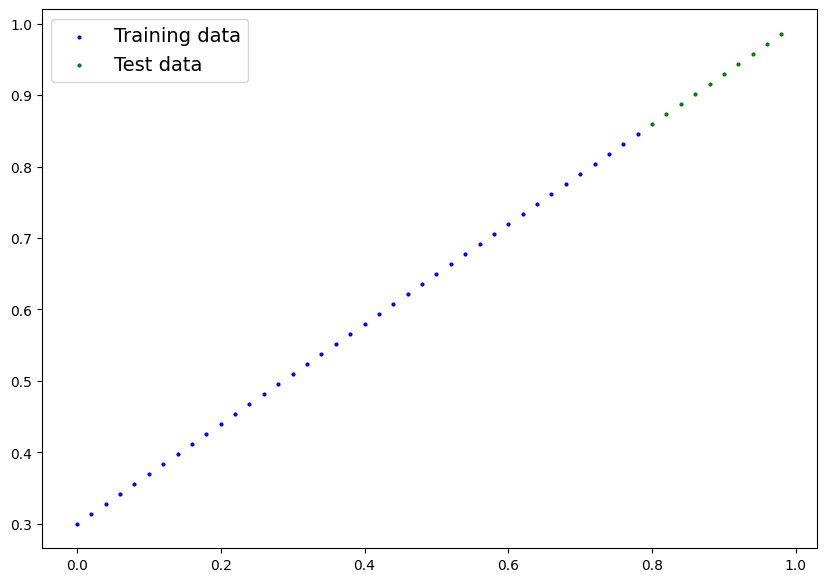

In [15]:
plot_prediction()

Visualize, Visualize and Visualize .... Whenever working with data and turtning it to numbers it is better to visualize it

In [16]:
import torch
from torch import nn

# Building First PyTorch model
# Creating a linear regression model class.

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # start with random weight; this will be adjusted as the model learns
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Linear regression formula: y = w * x + b
        return self.weights * x + self.bias


# Important note: here the nn.Modules has all the  building blocks for nn


In [17]:
### Chenking the content of the pytorch model
# creating a random_seed


torch.manual_seed(42)

model_0 = LinearRegressionModel()


list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [18]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Predication using `torch.inference_mode()`

In [19]:
# Make predictions with model

with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds



tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [20]:
# Checking the predictions
print(f"Number of testing samples:  {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values: \n{y_preds}")

Number of testing samples:  10
Number of predictions made: 10
Predicted values: 
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


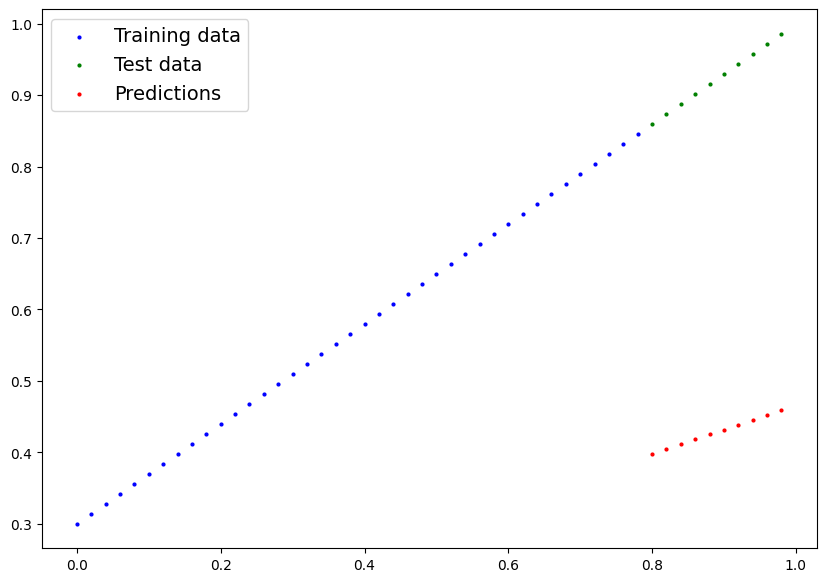

In [21]:
plot_prediction(predictions=y_preds)

In [22]:
y_test = y_preds

# Creating a loss function, which depnds on the type of problem we work

However there are some common values that are known to work well such as *SGD* or *Adam optimizer*. And *MAE* loss function for regression problems or binary cross entropy loss function for classification problems (predicting one thing or another)  

# Here we use MAE:  
Which measures the absolute difference between 2 points (predictions and labels )
and then takes the mean across all examples .

params : is the target model parameters you like to optimize ( eg: weights, and bias values we randomly set before )
lr : Learning rate : Higher means the optimizer try larger updates (these can sometimes be too large and optimizer doesn't work well ) lower means the optimizer try smaller updates ( these can sometimes be too small and optimizer will take too long to find the ideal values)

*Common values are* 0.01, 0.001, 0.0001




In [23]:
# Create a loss function:
loss_fn = nn.L1Loss()   # MAE loss is the same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),  # parameters of target model to optimize
                            lr=0.01) # # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))


follow this link for fun:  https://en.wikipedia.org/wiki/Neural_network_(machine_learning)

Whole idea of training is for a model to move from *Unknown* parameters to some *Known* parameters

Or from a poor representation to  a better representation of the data

Using Loss fn: is a good measure  ( aka cost fun:)



##Train Model

In [24]:
import torch

torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 4000

# Create empty loss lists to track the values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    # Training

    # Put the model in training mode (default, but still good practice)
    model_0.train()

    # 1. Forward pass on the training data
    y_pred = model_0(X_train)

    # 2. Calculate the loss (how different are our predictions from the truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero the gradients
    optimizer.zero_grad()

    # 4. Backward pass (compute gradients)
    loss.backward()  #
    # 5. Step the optimizer (update weights)
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():  # disables gradient calculation
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Calculate loss on test data
        test_loss = loss_fn(test_pred, y_test).type(torch.float)

    # Record and print every 10 epochs
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | MAE Train Loss: {loss.item():.4f} | MAE Test Loss: {test_loss.item():.4f}")


Epoch: 0 | MAE Train Loss: 0.3129 | MAE Test Loss: 0.0135
Epoch: 10 | MAE Train Loss: 0.1977 | MAE Test Loss: 0.1482
Epoch: 20 | MAE Train Loss: 0.0891 | MAE Test Loss: 0.2772
Epoch: 30 | MAE Train Loss: 0.0531 | MAE Test Loss: 0.3499
Epoch: 40 | MAE Train Loss: 0.0454 | MAE Test Loss: 0.3809
Epoch: 50 | MAE Train Loss: 0.0417 | MAE Test Loss: 0.3953
Epoch: 60 | MAE Train Loss: 0.0382 | MAE Test Loss: 0.4057
Epoch: 70 | MAE Train Loss: 0.0348 | MAE Test Loss: 0.4139
Epoch: 80 | MAE Train Loss: 0.0313 | MAE Test Loss: 0.4222
Epoch: 90 | MAE Train Loss: 0.0279 | MAE Test Loss: 0.4298
Epoch: 100 | MAE Train Loss: 0.0245 | MAE Test Loss: 0.4381
Epoch: 110 | MAE Train Loss: 0.0210 | MAE Test Loss: 0.4463
Epoch: 120 | MAE Train Loss: 0.0176 | MAE Test Loss: 0.4539
Epoch: 130 | MAE Train Loss: 0.0142 | MAE Test Loss: 0.4622
Epoch: 140 | MAE Train Loss: 0.0107 | MAE Test Loss: 0.4705
Epoch: 150 | MAE Train Loss: 0.0073 | MAE Test Loss: 0.4781
Epoch: 160 | MAE Train Loss: 0.0039 | MAE Test Loss

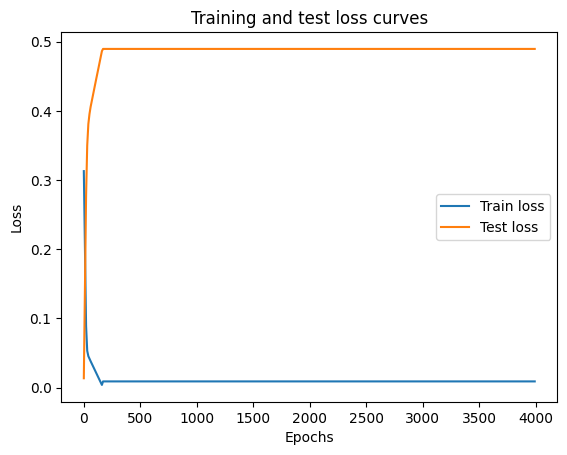

In [25]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## Making Predictions with a trained PyTorch model (inference)

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1)     Set the model in evaluation mode (model.eval()).

2)     Make the predictions using the inference mode context manager (with torch.inference_mode(): ...).
 3)    All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).


In [26]:
# Set the model in evaluation mode
model_0.eval()

# 2. SetUp the inference mode context manager
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

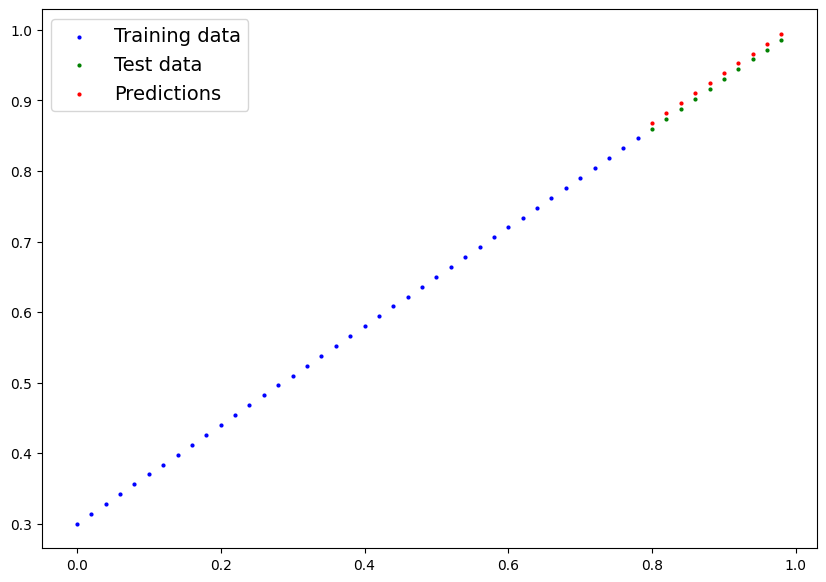

In [27]:
plot_prediction(predictions=y_preds)

## Saving Pytorch model's state_dict()


In [28]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [29]:
# Check the saved file path
!ls -l models/01_pytorch_workflow_model_0.pth


-rw-r--r-- 1 root root 2117 Oct 26 04:43 models/01_pytorch_workflow_model_0.pth


## Loading the saved pytorch model's state_dict()

In [30]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state dict of our saved model (this will update the new instance of our model with trained weights)

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [31]:
# Put the loaded model to the evaluation mode
loaded_model_0.eval()

# 2. Use the inference mode context manager to make predictions
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)   # Perform a forward pass on the test data with the loaded model


In [32]:
# Compare previous model predictions with loaded model prediction (these should be same )
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

It looks like that model predictions are the same as the previous model predications (predictions made prior to saving) . This indicates our model is saving and loading as expected

## Summary ##


In [33]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Checking the version of python
torch.__version__


'2.8.0+cu126'

In [34]:
# making the code device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f" using device: {device}")

 using device: cuda


#Data

In [35]:
# creating  weight and bias
weight = 0.7
bias = 0.3

# Create range of values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels )
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [36]:
# we use an 80/20 split with 80% of training data and 20% of testing data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]

X_test, y_test =X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

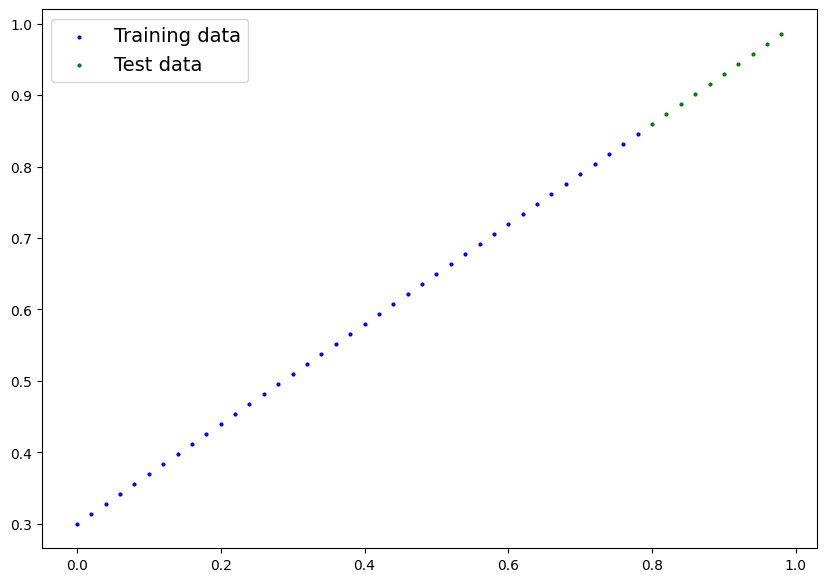

In [37]:
plot_prediction(X_train, y_train, X_test, y_test)

In [53]:
import torch

# 1. Choose device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Move model to device
model_1.to(device)

# 3. Move data to same device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


Using device: cuda


In [54]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use the nn.Linear() for creating the model parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

    # Define the forward computations (input data x flows through the nn.Linear())
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed when creating the model (this is not always needed but is used for demonstration purpose)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1 , model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [55]:
# Check for model device
next(model_1.parameters()).device


device(type='cpu')

In [56]:
# Set model to GPU if it's available, otherwise it'll default to CPU
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='cuda', index=0)

#Training

In [57]:
# Create a loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),  # optimize newly created model's parameters
                            lr=0.01)

In [58]:
torch.manual_seed(42)

# set the number of epochs
epochs = 1000

# Put the data on the available device
# Without this, error will happen (not all model/data on device)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
  # training
  model_1.train()

  # 1 Forward pass
  y_pred = model_1(X_train)

  # 2 Calculate loss
  loss = loss_fn(y_pred, y_train)

  # 3 Zero grad optimizer
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5 Step the optimizer
  optimizer.step()

  # Testing
  model_1.eval()

  # 1 Foward pass
  with torch.inference_mode():
    test_pred = model_1(X_test)

    # 2 calculate the loss
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Train loss : {loss} | Test loss {test_loss}")

Epoch: 0 | Train loss : 0.5551779866218567 | Test loss 0.5739762187004089
Epoch: 100 | Train loss : 0.006215683650225401 | Test loss 0.014086711220443249
Epoch: 200 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 300 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 400 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 500 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 600 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 700 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 800 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882
Epoch: 900 | Train loss : 0.0012645035749301314 | Test loss 0.013801801018416882


In [59]:
# Finding the learned parameters
from pprint import pprint # pprint == pretyprint

print("The model learned following values for weights and bias:")
pprint(model_1.state_dict())
print("/nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: { bias}")

The model learned following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])
/nAnd the original values for weights and bias are:
weights: 0.7, bias: 0.3


## making predictions


In [60]:
# Trun model into evaluation mode
model_1.eval()

# Make the predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

Note: Many data science libraries such as pandas, matplotlib and NumPy aren't capable of using data that is stored on GPU. So you might run into some issues when trying to use a function from one of these libraries with tensor data not stored on the CPU. To fix this, you can call .cpu() on your target tensor to return a copy of your target tensor on the CPU.

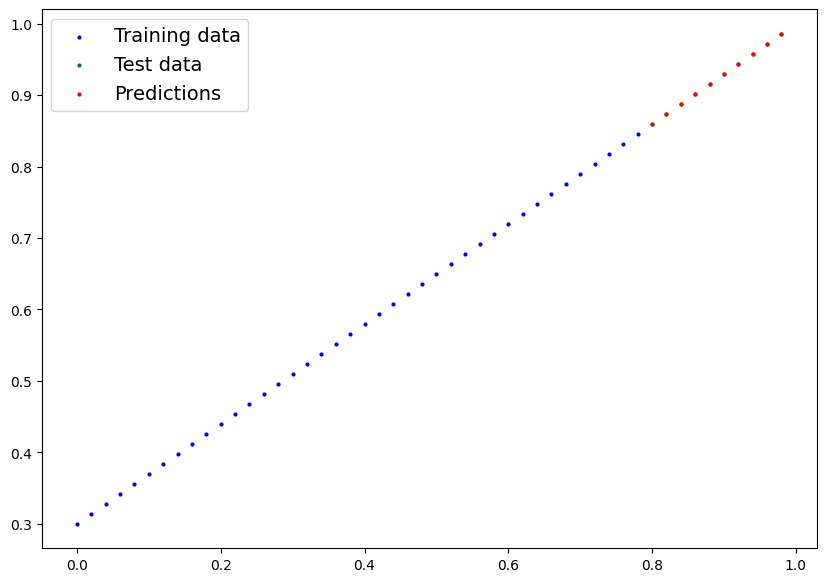

In [62]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_prediction(predictions=y_preds.cpu())


## Saving and loading model ##


In [64]:
from pathlib import Path

# 1 Creating models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2 Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3 Save the model state dict
print(f" Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

 Saving model to: models/01_pytorch_workflow_model_1.pth


Loading the data back to make sure everything work well

In [65]:
# Instantiate a fresh instance of LinearRegressionModelV2
loaded_model_1 = LinearRegressionModelV2()

# Load model state dict
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Put the model to target device ( if your data is on GPU , model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded Model:\n{loaded_model_1}")
print(f"model on device:\n {next(loaded_model_1.parameters()).device}")

Loaded Model:
LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
model on device:
 cuda:0


In [67]:
# Evaluating the loaded model
loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')